# Hippocampal place cells in rat CA1 (DANDI:000044)

This notebook demonstrates the defining property of hippocampal place cells: a
pyramidal neuron in area CA1 fires selectively when the animal occupies a
restricted portion of the environment, and the population of such cells tiles
the whole environment densely enough that the animal's position can be read
back out from spiking alone.

**Data.** [DANDI:000044](https://dandiarchive.org/dandiset/000044), *"Diversity
in neural firing dynamics supports both rigid and learned hippocampal
sequences"* (Grosmark & Buzsáki, *Science* 2016; the `hc-11` dataset).  Eight
bilateral silicon-probe recordings from dorsal CA1 of four male Long-Evans
rats.  Each session concatenates a ~4 h PRE sleep epoch in the home cage, a
novel MAZE running epoch (~35-90 min) in an unfamiliar room, and a ~4 h POST
sleep epoch.  Spikes are already sorted and each unit is labelled `excitatory`
or `inhibitory`.  We use only the MAZE epoch.

Five of the eight sessions used a linear platform (four on a 1.6 m track, one
on a 2 m track); the remaining three used a circular platform and are excluded
so that a single linear coordinate means the same thing everywhere.  We
prototype on `sub-Achilles/ses-Achilles-10252013` and then repeat the whole
pipeline on all five linear sessions.

**Analysis.**

1. Stream the NWB files from the archive with LINDI (the source files are
   5-9 GB each; we never download one in full).
2. Restrict to periods of active running on the track and split them by travel
   direction.
3. Build occupancy-normalised firing-rate maps with pynapple.
4. Test each unit's Skaggs spatial information against a circular-shift null.
5. Show the population tiling, its direction selectivity, and cross-validated
   Bayesian decoding of position from the population.

## Setup

In [1]:
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pynapple as nap
from matplotlib.gridspec import GridSpec
from tqdm.auto import tqdm

import place_cells_lib as L

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9, "legend.fontsize": 8,
})

RIGHT_C, LEFT_C = "#1f77b4", "#d62728"
rng = np.random.default_rng(0)

## 1. Load one session and inspect every stream before analysing it

`place_cells_lib.load_session` opens the asset through LINDI, pulls out the
epoch table, the linearized position, the raw 2-D position and the sorted
units, and derives running speed from the linear coordinate.

Two details about this particular conversion are worth stating explicitly.
First, the position `TimeSeries` stores the sampling *period* (0.0256 s) in its
`rate` field rather than the rate; `n_samples * rate` reproduces the MAZE epoch
duration to within a millisecond, which is how we verify the timebase.  Second,
the linearized coordinate is left as NaN whenever the animal is off the track
proper (in the reward areas past either end), so roughly 13% of MAZE samples
carry a usable position.  That is the curation the original authors applied and
it is exactly the restriction a 1-D place-field analysis wants.

In [2]:
SESSION = L.SESSIONS[0]
sess = L.load_session(SESSION)
lin, xy, speed, dt = sess["lin"], sess["xy"], sess["speed"], sess["dt"]
maze_ep = sess["maze_ep"]

print(sess["epochs"][["start_time", "stop_time", "label"]])
print()
print(sess["units"])

Achilles 10252013: maze 2068 s, 137 units, tracking valid on 13% of samples, dt=25.60 ms
    start_time   stop_time      label
id                                   
0          0.0  18079.5000   PREEpoch
1      18079.5  20147.0000  MazeEpoch
2      20147.0  34861.1032  POSTEpoch

  Index      rate  cell_type    location      shank_id
-------  --------  -----------  ----------  ----------
      1   0.97547  excitatory   lCA1                 0
      2   8.46457  inhibitory   lCA1                 1
      6   0.18602  excitatory   lCA1                 5
      7   1.46025  excitatory   lCA1                 6
      9   0.26038  excitatory   lCA1                 8
     11   0.43266  excitatory   lCA1                10
     12   1.30016  excitatory   lCA1                11
     13   0.81065  excitatory   lCA1                12
     16   1.05553  excitatory   lCA1                15
     18   6.55046  inhibitory   lCA1                17
     20   9.87773  inhibitory   lCA1                19
     

### Run epochs

A sample counts as running when the position is tracked and the speed exceeds
5 cm/s.  Contiguous samples are merged into intervals, intervals shorter than
0.5 s are dropped, and the remainder are split by the sign of the velocity.
Separating the two travel directions matters on a linear track: CA1 fields
there are strongly direction selective, and pooling directions blurs them.

In [3]:
eps = L.run_epochs(lin, speed, dt)
for name in ("right", "left", "run"):
    print(f"{name:6s}: {len(eps[name]):3d} traversals, "
          f"{float(eps[name].tot_length()):6.1f} s total")

pyr = L.select_pyramidal(sess["units"], ep=eps["run"])
inh = sess["units"][np.array(sess["units"].metadata["cell_type"]) == "inhibitory"]
print(f"\n{len(pyr)} pyramidal units kept (of "
      f"{(np.array(sess['units'].metadata['cell_type']) == 'excitatory').sum()} excitatory), "
      f"{len(inh)} interneurons")

right :  60 traversals,  124.6 s total
left  :  50 traversals,  102.5 s total
run   : 110 traversals,  227.1 s total

114 pyramidal units kept (of 120 excitatory), 17 interneurons


### Figure 1: session overview

Raw behaviour and raw spiking, before any analysis.

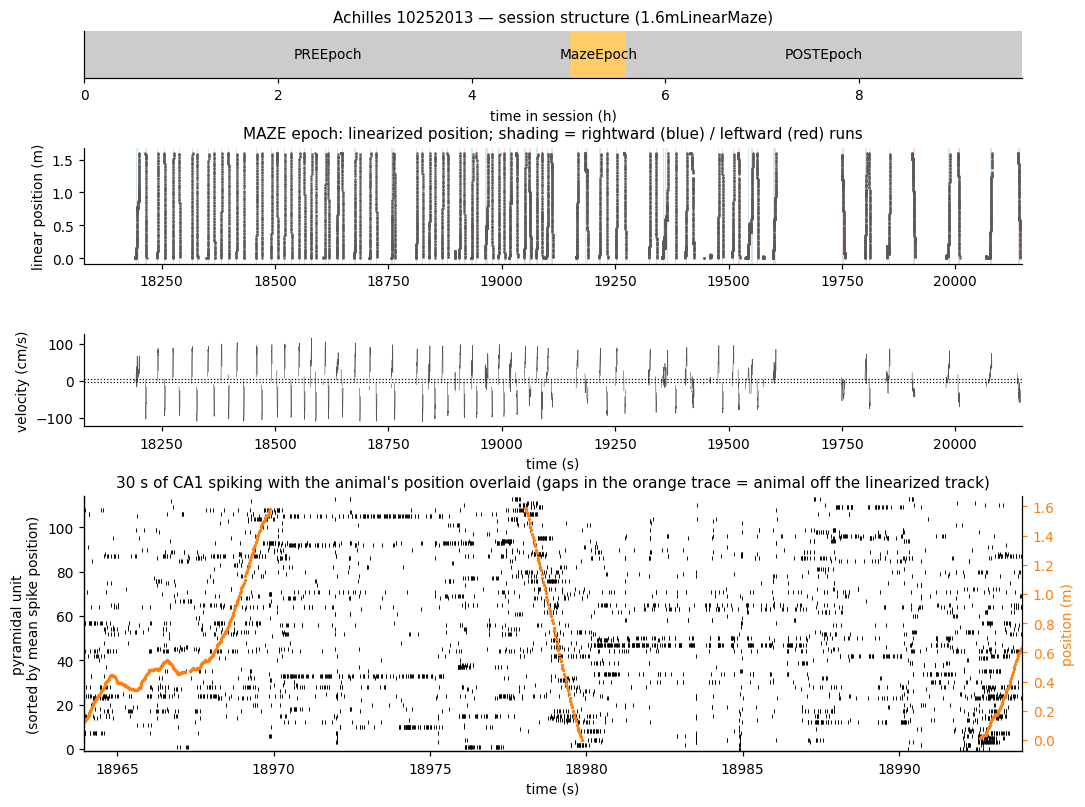

In [4]:
fig = plt.figure(figsize=(11, 8.5))
gs = GridSpec(4, 1, height_ratios=[0.4, 1, 0.8, 2.2], hspace=0.55)

ax = fig.add_subplot(gs[0])
for _, row in sess["epochs"].iterrows():
    c = "#ffcc66" if "Maze" in row.label else "#cccccc"
    ax.axvspan(row.start_time / 3600, row.stop_time / 3600, color=c)
    ax.text((row.start_time + row.stop_time) / 7200, 0.5, row.label,
            ha="center", va="center", fontsize=9)
ax.set_xlim(0, sess["epochs"].stop_time.max() / 3600)
ax.set_yticks([])
ax.set_xlabel("time in session (h)")
ax.set_title(f"{SESSION['subject']} {SESSION['session']} — session structure "
             f"({SESSION['maze']})")

ax = fig.add_subplot(gs[1])
ax.plot(lin.t, lin.values, ".", ms=1.2, color="0.35", rasterized=True)
for name, c in (("right", RIGHT_C), ("left", LEFT_C)):
    for st, en in zip(eps[name].start, eps[name].end):
        ax.axvspan(st, en, color=c, alpha=0.18, lw=0)
ax.set_ylabel("linear position (m)")
ax.set_title("MAZE epoch: linearized position; shading = rightward (blue) / leftward (red) runs")
ax.set_xlim(maze_ep.start[0], maze_ep.end[0])

ax = fig.add_subplot(gs[2])
ax.plot(speed.t, 100 * speed.values, lw=0.4, color="0.35", rasterized=True)
ax.axhline(100 * L.SPEED_THRESHOLD, color="k", ls=":", lw=0.8)
ax.axhline(-100 * L.SPEED_THRESHOLD, color="k", ls=":", lw=0.8)
ax.set_ylabel("velocity (cm/s)")
ax.set_xlabel("time (s)")
ax.set_xlim(maze_ep.start[0], maze_ep.end[0])

# Zoomed raster over the 30 s window that contains the most traversals
WIN_LEN = 30.0
mids = (np.asarray(eps["run"].start) + np.asarray(eps["run"].end)) / 2
counts = [np.sum(np.abs(mids - m) < WIN_LEN / 2) for m in mids]
centre = mids[int(np.argmax(counts))]
win = nap.IntervalSet(start=centre - WIN_LEN / 2, end=centre + WIN_LEN / 2)

ax = fig.add_subplot(gs[3])
mean_pos = np.array([np.nanmean(pyr[k].restrict(eps["run"]).value_from(lin).values)
                     if len(pyr[k].restrict(eps["run"])) > 3 else np.nan
                     for k in pyr.keys()])
order_units = np.argsort(np.where(np.isfinite(mean_pos), mean_pos, np.inf))
keys = list(pyr.keys())
for row, i in enumerate(order_units):
    st = pyr[keys[i]].restrict(win).t
    ax.plot(st, np.full(st.size, row), "|", ms=3, color="k", mew=0.6)
ax2 = ax.twinx()
ax2.plot(lin.restrict(win).t, lin.restrict(win).values, ".", color="#ff7f0e", ms=2.5)
ax2.set_ylabel("position (m)", color="#ff7f0e")
ax2.tick_params(axis="y", colors="#ff7f0e")
ax2.spines["right"].set_visible(True)
ax.set_xlim(win.start[0], win.end[0])
ax.set_ylim(-1, len(pyr))
ax.set_ylabel("pyramidal unit\n(sorted by mean spike position)")
ax.set_xlabel("time (s)")
ax.set_title(f"{WIN_LEN:.0f} s of CA1 spiking with the animal's position overlaid "
             "(gaps in the orange trace = animal off the linearized track)")

fig.savefig(f"{FIGDIR}/fig01_session_overview.png", bbox_inches="tight")
plt.show()

The raster is already suggestive: as the position trace sweeps up and down the
track, the active band of units sweeps with it.

### Figure 2: behaviour and raw LFP

A check that the linearization is faithful, that occupancy is reasonably even
across the track, and a look at the raw wideband-derived LFP to confirm that
running is accompanied by the expected hippocampal theta rhythm.

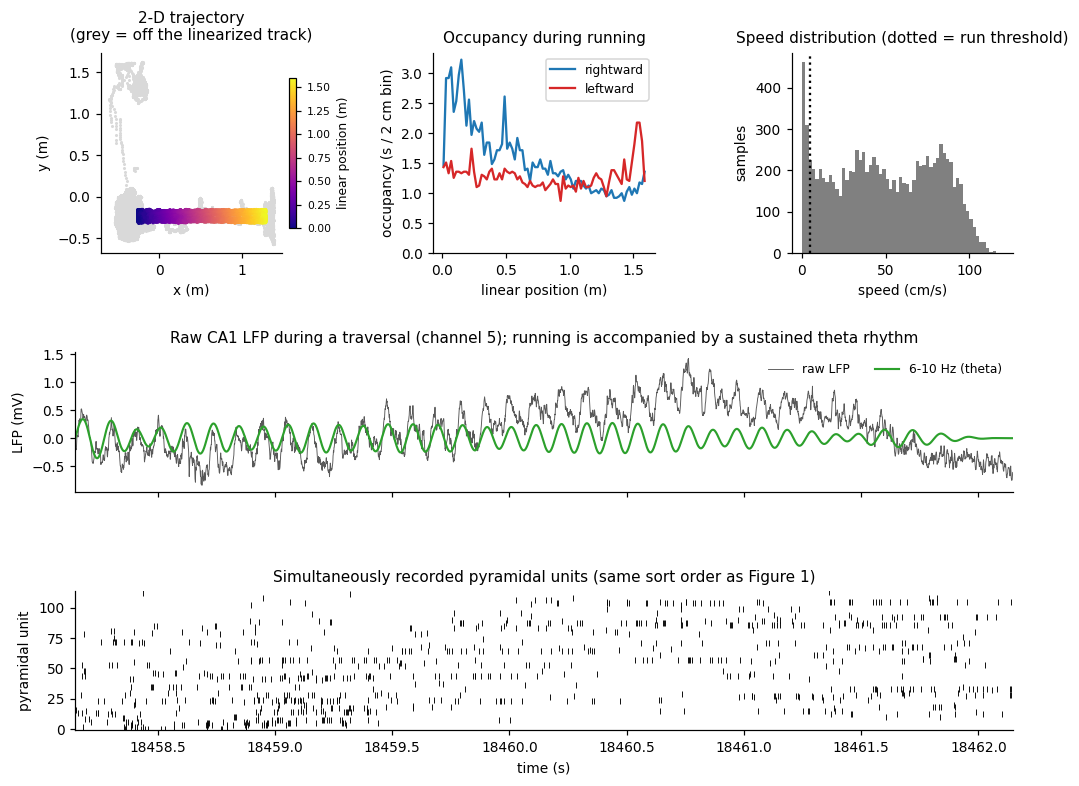

In [5]:
lfp_es = sess["nwbfile"].processing["ecephys"]["LFP"]["LFP"]
lfp_fs = 1250.0
SNIP_LEN = 4.0
snip_t0 = float(eps["right"].start[10]) - 0.5
i0 = int(snip_t0 * lfp_fs)
n_snip = int(SNIP_LEN * lfp_fs)
lfp_snip = np.asarray(lfp_es.data[i0:i0 + n_snip, :16], dtype=float) * lfp_es.conversion
lfp_t = snip_t0 + np.arange(n_snip) / lfp_fs
best_ch = int(np.argmax(np.std(lfp_snip, axis=0)))
lfp_tsd = nap.Tsd(t=lfp_t, d=1e3 * lfp_snip[:, best_ch])
theta = nap.apply_bandpass_filter(lfp_tsd, (6.0, 10.0), fs=lfp_fs)

fig = plt.figure(figsize=(11, 8))
gs = GridSpec(3, 3, height_ratios=[1.15, 0.8, 0.8], hspace=0.62, wspace=0.62)

ax = fig.add_subplot(gs[0, 0])
ok = np.isfinite(xy.values[:, 0])
ax.scatter(xy.values[ok, 0], xy.values[ok, 1], c="0.85", s=1, rasterized=True)
okl = np.isfinite(lin.values)
sc = ax.scatter(xy.values[okl, 0], xy.values[okl, 1], c=lin.values[okl], s=2,
                cmap="plasma", rasterized=True)
cb = plt.colorbar(sc, ax=ax, fraction=0.035, pad=0.03, shrink=0.75)
cb.set_label("linear position (m)", fontsize=8)
cb.ax.tick_params(labelsize=7)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("2-D trajectory\n(grey = off the linearized track)", pad=8)

ax = fig.add_subplot(gs[0, 1])
for name, c in (("right", RIGHT_C), ("left", LEFT_C)):
    _, cen, occ = L.rate_maps(pyr, lin, eps[name], minmax=(0, float(np.nanmax(lin.values))))
    ax.plot(cen, occ, color=c, label=f"{name}ward")
ax.set_xlabel("linear position (m)")
ax.set_ylabel("occupancy (s / 2 cm bin)")
ax.set_ylim(bottom=0)
ax.legend()
ax.set_title("Occupancy during running")

ax = fig.add_subplot(gs[0, 2])
sp = 100 * np.abs(speed.values[np.isfinite(speed.values)])
ax.hist(sp, bins=60, range=(0, 120), color="0.5")
ax.axvline(100 * L.SPEED_THRESHOLD, color="k", ls=":")
ax.set_xlabel("speed (cm/s)")
ax.set_ylabel("samples")
ax.set_title("Speed distribution (dotted = run threshold)")

ax = fig.add_subplot(gs[1, :])
ax.plot(lfp_tsd.t, lfp_tsd.values, lw=0.6, color="0.35", label="raw LFP")
ax.plot(theta.t, theta.values, lw=1.4, color="#2ca02c", label="6-10 Hz (theta)")
ax.set_ylabel("LFP (mV)")
ax.set_xlim(snip_t0, snip_t0 + SNIP_LEN)
ax.legend(loc="upper right", ncol=2, frameon=False)
ax.tick_params(labelbottom=False)
ax.set_title(f"Raw CA1 LFP during a traversal (channel {best_ch}); running is "
             "accompanied by a sustained theta rhythm")

ax = fig.add_subplot(gs[2, :], sharex=ax)
snip_ep = nap.IntervalSet(snip_t0, snip_t0 + SNIP_LEN)
for row, i in enumerate(order_units):
    st = pyr[keys[i]].restrict(snip_ep).t
    ax.plot(st, np.full(st.size, row), "|", ms=4, color="k", mew=0.6)
ax.set_xlabel("time (s)")
ax.set_ylabel("pyramidal unit")
ax.set_ylim(-1, len(pyr))
ax.set_title("Simultaneously recorded pyramidal units (same sort order as Figure 1)")

fig.savefig(f"{FIGDIR}/fig02_behavior_and_lfp.png", bbox_inches="tight")
plt.show()

## 2. Firing-rate maps and the shuffle test

For each direction we bin the track into 2 cm bins, divide the number of spikes
in each bin by the time the animal spent there, and smooth the result with a
Gaussian of 1.5 bins (3 cm).  `nap.compute_tuning_curves` does the
occupancy normalisation; the epochs argument restricts it to the runs of one
direction.

Spatial selectivity is quantified with Skaggs information,

$$I = \sum_i p_i \frac{r_i}{\bar r} \log_2 \frac{r_i}{\bar r} \quad
\text{[bits per spike]},$$

where $p_i$ is the occupancy probability of bin $i$ and $r_i$ its firing rate.
Because $I$ is biased upward for sparsely firing cells, significance is
assessed against a null built by circularly shifting each spike train inside
the concatenated run epochs by a random offset.  That destroys the
spike-position relationship while preserving each unit's spike count and its
fine-timescale autocorrelation.  A unit counts as a place cell in a direction
if its information exceeds the 95th percentile of its own null **and** its peak
rate is at least 1 Hz.

In [6]:
res = {}
minmax = (float(np.nanmin(lin.values)), float(np.nanmax(lin.values)))
for i, d in enumerate(("right", "left")):
    res[d] = L.analyze_direction(pyr, lin, eps[d], n_shuffles=L.N_SHUFFLES,
                                 seed=i, minmax=minmax)
centers = res["right"]["centers"]

is_place_any = res["right"]["is_place"] | res["left"]["is_place"]
print(f"place cells: {res['right']['is_place'].sum()} rightward, "
      f"{res['left']['is_place'].sum()} leftward, "
      f"{is_place_any.sum()}/{len(pyr)} ({100 * is_place_any.mean():.0f}%) in at least one direction")
for d in ("right", "left"):
    m = res[d]["is_place"]
    print(f"  {d:5s}: SI {np.median(res[d]['si'][m]):.2f} bits/spike, "
          f"peak {np.median(res[d]['peak_rate'][m]):.1f} Hz, "
          f"field width {np.nanmedian(res[d]['width'][m]) * 100:.0f} cm, "
          f"sparsity {np.nanmedian(res[d]['sparsity'][m]):.2f}")

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

place cells: 78 rightward, 81 leftward, 99/114 (87%) in at least one direction
  right: SI 0.73 bits/spike, peak 6.8 Hz, field width 22 cm, sparsity 0.46
  left : SI 0.85 bits/spike, peak 6.2 Hz, field width 26 cm, sparsity 0.41


/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-4-8/placefields-02/place_cells_lib.py:248: RuntimeWarning: invalid value encountered in divide
  return np.where(den > 0, num / den, np.nan)


### Figure 3: individual place cells

For six example cells: on the left, every spike plotted at the position and lap
on which it occurred (a "spike raster in space"); on the right, the resulting
rate map for each direction.

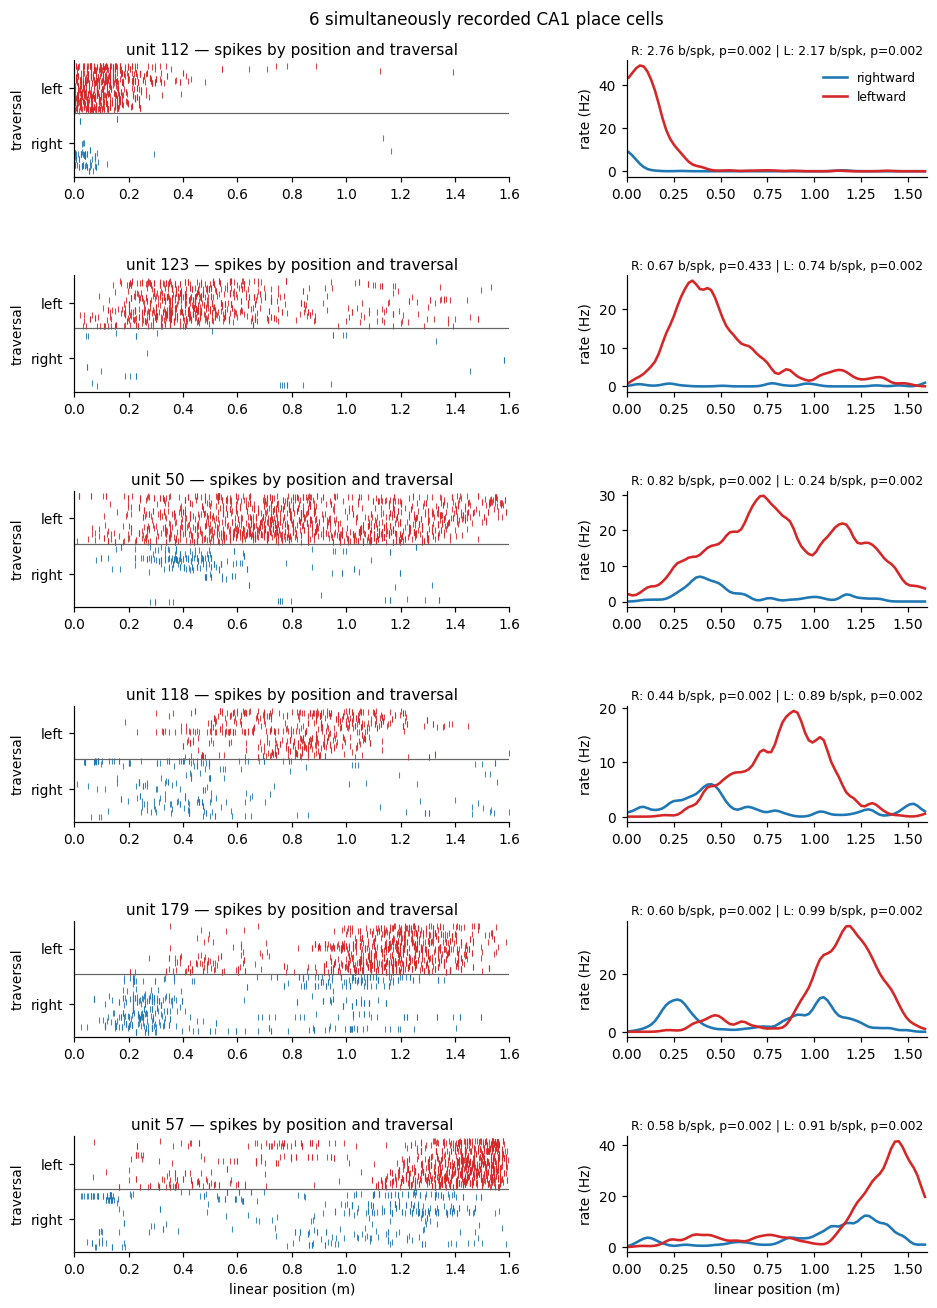

In [7]:
def lap_spike_positions(unit, lin, ep):
    """Position and lap index of every spike a unit fired inside ``ep``."""
    laps, pos = [], []
    for i in range(len(ep)):
        one = ep[i]
        st = unit.restrict(one)
        if len(st) == 0:
            continue
        p = st.value_from(lin).values
        good = np.isfinite(p)
        laps.append(np.full(good.sum(), i))
        pos.append(p[good])
    if not laps:
        return np.array([]), np.array([])
    return np.concatenate(pos), np.concatenate(laps)


# Pick one place cell per sixth of the track, so the examples span the
# environment rather than clustering.  Within a sixth we take the strongest
# firing cell rather than the most informative one: spatial information is
# inflated for very sparsely firing units, which make poor illustrations.
best_si = np.maximum(np.where(res["right"]["is_place"], res["right"]["si"], -np.inf),
                     np.where(res["left"]["is_place"], res["left"]["si"], -np.inf))
peak_any = np.where(res["right"]["peak_rate"] > res["left"]["peak_rate"],
                    res["right"]["peak_pos"], res["left"]["peak_pos"])
max_peak = np.maximum(res["right"]["peak_rate"], res["left"]["peak_rate"])
edges = np.linspace(minmax[0], minmax[1], 7)
examples = []
for lo, hi in zip(edges[:-1], edges[1:]):
    pool = np.where(is_place_any & (best_si > 0.5) & (peak_any >= lo) & (peak_any < hi)
                    & ~np.isin(np.arange(len(pyr)), examples))[0]
    if pool.size:
        examples.append(int(pool[np.argmax(max_peak[pool])]))

unit_ids = list(pyr.keys())
n_right = len(eps["right"])
fig, axes = plt.subplots(len(examples), 2, figsize=(10, 2.15 * len(examples)),
                         gridspec_kw=dict(width_ratios=[1.45, 1], hspace=0.85, wspace=0.32))
for row, idx in enumerate(examples):
    uid = unit_ids[idx]
    axr, axt = axes[row]
    for d, c, off in (("right", RIGHT_C, 0), ("left", LEFT_C, n_right + 4)):
        p, lap = lap_spike_positions(pyr[uid], lin, eps[d])
        axr.plot(p, lap + off, "|", ms=3.5, mew=0.7, color=c, alpha=0.85)
        axt.plot(centers, res[d]["rates"][idx], color=c, lw=1.7,
                 label=f"{d}ward" if row == 0 else None)
    axr.axhline(n_right + 2, color="0.4", lw=0.8)
    axr.set_yticks([n_right / 2, n_right + 4 + len(eps["left"]) / 2])
    axr.set_yticklabels(["right", "left"])
    axr.set_xlim(minmax)
    axr.set_ylabel("traversal")
    axr.set_title(f"unit {uid} — spikes by position and traversal", pad=4)
    axt.set_xlim(minmax)
    axt.set_ylabel("rate (Hz)")
    txt = " | ".join(
        f"{d[0].upper()}: {res[d]['si'][idx]:.2f} b/spk, p={res[d]['pval'][idx]:.3f}"
        for d in ("right", "left"))
    axt.set_title(txt, pad=4, fontsize=8)
    if row == 0:
        axt.legend(loc="upper right", frameon=False)
    if row == len(examples) - 1:
        axr.set_xlabel("linear position (m)")
        axt.set_xlabel("linear position (m)")
fig.subplots_adjust(top=0.95)
fig.suptitle(f"{len(examples)} simultaneously recorded CA1 place cells", y=0.985,
             fontsize=11)
fig.savefig(f"{FIGDIR}/fig03_example_place_cells.png", bbox_inches="tight")
plt.show()

Each cell fires in a single compact stretch of the track, repeatably across
tens of traversals, and in most cases only in one travel direction.

### Figure 4: the population tiles the track, separately for each direction

Rate maps are peak-normalised and sorted by the location of the rightward
peak.  If the same sort order is applied to the leftward maps and the diagonal
survives, fields are direction independent; if it dissolves, they are
direction selective.

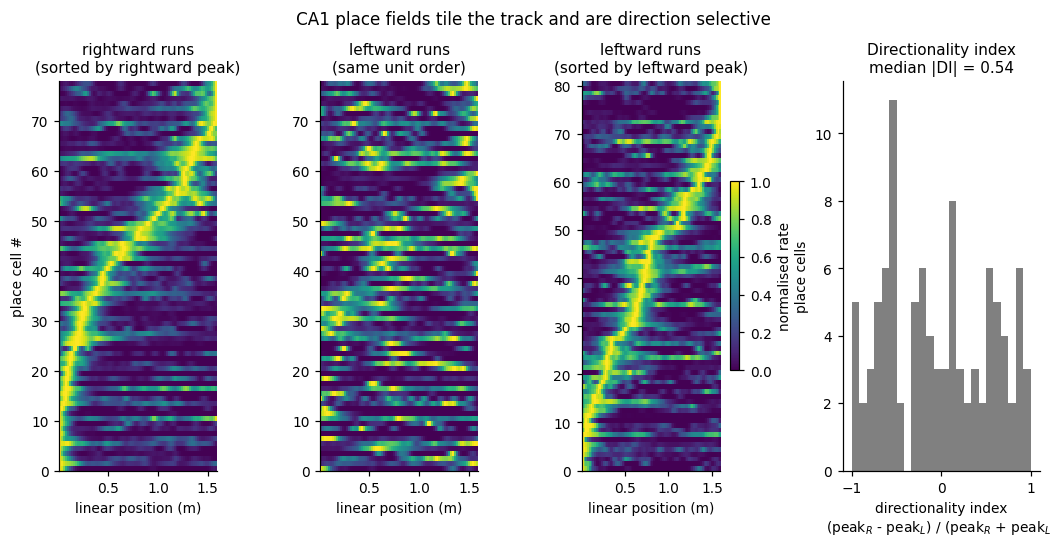

In [8]:
def sorted_maps(rates, mask):
    r = rates[mask]
    pk = np.nanmax(r, axis=1, keepdims=True)
    return np.where(pk > 0, r / np.where(pk > 0, pk, 1.0), 0.0)


mask = res["right"]["is_place"]
order = np.argsort(res["right"]["peak_pos"][mask])
mR = sorted_maps(res["right"]["rates"], mask)[order]
mL = sorted_maps(res["left"]["rates"], mask)[order]

maskL = res["left"]["is_place"]
orderL = np.argsort(res["left"]["peak_pos"][maskL])
mL_own = sorted_maps(res["left"]["rates"], maskL)[orderL]

fig = plt.figure(figsize=(11.5, 4.6))
gs = GridSpec(1, 4, wspace=0.62, width_ratios=[1, 1, 1, 1.25])
ext = [centers[0], centers[-1], 0, mR.shape[0]]
for j, (m, title) in enumerate([
        (mR, "rightward runs\n(sorted by rightward peak)"),
        (mL, "leftward runs\n(same unit order)"),
]):
    ax = fig.add_subplot(gs[j])
    im = ax.imshow(m, aspect="auto", origin="lower", extent=ext, cmap="viridis",
                   vmin=0, vmax=1, interpolation="nearest")
    ax.set_xlabel("linear position (m)")
    ax.set_ylabel("place cell #" if j == 0 else "")
    ax.set_title(title)
ax = fig.add_subplot(gs[2])
im = ax.imshow(mL_own, aspect="auto", origin="lower",
               extent=[centers[0], centers[-1], 0, mL_own.shape[0]], cmap="viridis",
               vmin=0, vmax=1, interpolation="nearest")
ax.set_xlabel("linear position (m)")
ax.set_title("leftward runs\n(sorted by leftward peak)")
cb = plt.colorbar(im, ax=ax, fraction=0.06, pad=0.06)
cb.set_label("normalised rate")

ax = fig.add_subplot(gs[3])
di = L.directionality_index(res)
ax.hist(di[is_place_any], bins=np.linspace(-1, 1, 25), color="0.5")
ax.set_xlabel("directionality index\n(peak$_R$ - peak$_L$) / (peak$_R$ + peak$_L$)")
ax.set_ylabel("place cells")
ax.set_title("Directionality index\n"
             f"median |DI| = {np.nanmedian(np.abs(di[is_place_any])):.2f}")
fig.suptitle("CA1 place fields tile the track and are direction selective", y=1.02,
             fontsize=11)
fig.savefig(f"{FIGDIR}/fig04_population_maps.png", bbox_inches="tight")
plt.show()

### Figure 5: spatial information against the shuffle null, and field statistics

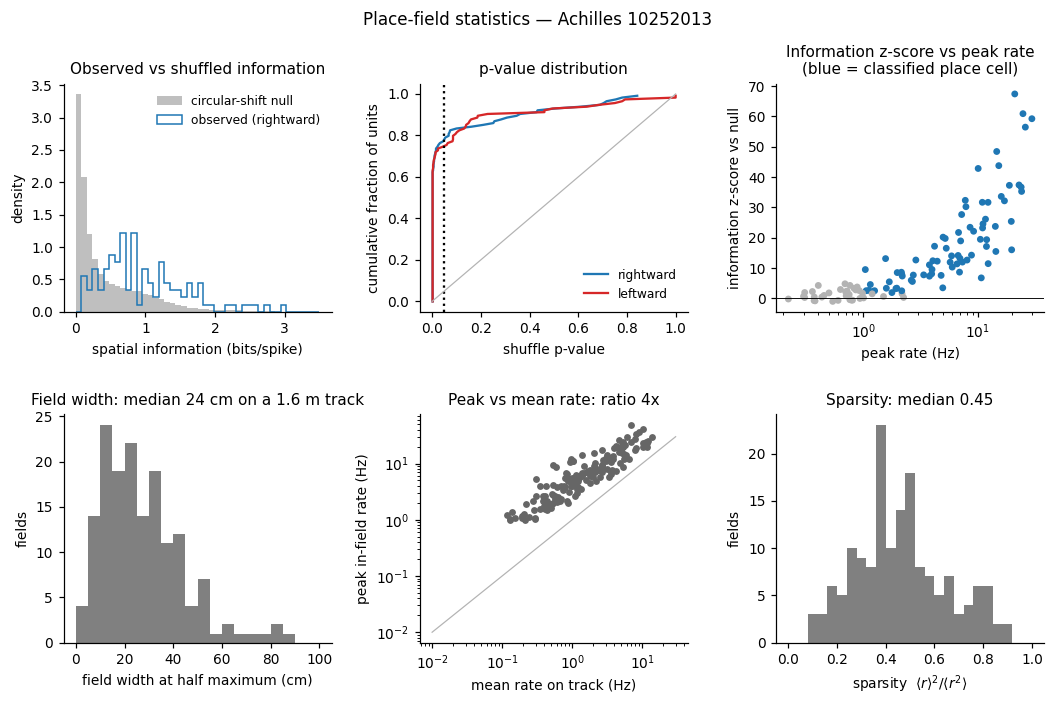

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.6))
fig.subplots_adjust(hspace=0.45, wspace=0.33)

ax = axes[0, 0]
bins = np.linspace(0, max(3.5, np.nanmax(res["right"]["si"]) * 1.05), 45)
ax.hist(res["right"]["null"].ravel(), bins=bins, density=True, color="0.75",
        label="circular-shift null")
ax.hist(res["right"]["si"], bins=bins, density=True, histtype="step", lw=1.8,
        color=RIGHT_C, label="observed (rightward)")
ax.set_xlabel("spatial information (bits/spike)")
ax.set_ylabel("density")
ax.legend(frameon=False)
ax.set_title("Observed vs shuffled information")

ax = axes[0, 1]
for d, c in (("right", RIGHT_C), ("left", LEFT_C)):
    ax.plot(np.sort(res[d]["pval"]), np.arange(len(pyr)) / len(pyr), color=c,
            label=f"{d}ward")
ax.axvline(0.05, color="k", ls=":")
ax.plot([0, 1], [0, 1], color="0.7", lw=0.8)
ax.set_xlabel("shuffle p-value")
ax.set_ylabel("cumulative fraction of units")
ax.legend(frameon=False)
ax.set_title("p-value distribution")

ax = axes[0, 2]
z = ((res["right"]["si"] - res["right"]["null"].mean(0))
     / res["right"]["null"].std(0))
ax.scatter(res["right"]["peak_rate"], z, s=12,
           c=np.where(res["right"]["is_place"], RIGHT_C, "0.7"))
ax.axhline(0, color="k", lw=0.6)
ax.set_xscale("log")
ax.set_xlabel("peak rate (Hz)")
ax.set_ylabel("information z-score vs null")
ax.set_title("Information z-score vs peak rate\n(blue = classified place cell)")

ax = axes[1, 0]
w = np.concatenate([res[d]["width"][res[d]["is_place"]] for d in ("right", "left")])
ax.hist(100 * w[np.isfinite(w)], bins=np.arange(0, 105, 5), color="0.5")
ax.set_xlabel("field width at half maximum (cm)")
ax.set_ylabel("fields")
ax.set_title(f"Field width: median {100 * np.nanmedian(w):.0f} cm "
             f"on a {minmax[1]:.1f} m track")

ax = axes[1, 1]
pk = np.concatenate([res[d]["peak_rate"][res[d]["is_place"]] for d in ("right", "left")])
mn = np.concatenate([res[d]["mean_rate"][res[d]["is_place"]] for d in ("right", "left")])
ax.scatter(mn, pk, s=12, color="0.4")
ax.plot([0.01, 30], [0.01, 30], color="0.7", lw=0.8)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("mean rate on track (Hz)")
ax.set_ylabel("peak in-field rate (Hz)")
ax.set_title(f"Peak vs mean rate: ratio {np.median(pk / mn):.0f}x")

ax = axes[1, 2]
spa = np.concatenate([res[d]["sparsity"][res[d]["is_place"]] for d in ("right", "left")])
ax.hist(spa[np.isfinite(spa)], bins=np.linspace(0, 1, 26), color="0.5")
ax.set_xlabel("sparsity  $\\langle r\\rangle^2 / \\langle r^2\\rangle$")
ax.set_ylabel("fields")
ax.set_title(f"Sparsity: median {np.nanmedian(spa):.2f}")

fig.suptitle(f"Place-field statistics — {SESSION['subject']} {SESSION['session']}",
             y=0.98, fontsize=11)
fig.savefig(f"{FIGDIR}/fig05_statistics.png", bbox_inches="tight")
plt.show()

## 3. Reading position back out of the population

If the population really carries a spatial code, position should be decodable
from spike counts alone.  We use pynapple's Bayesian decoder with a Poisson
likelihood, and we cross-validate: rate maps are estimated from the
odd-numbered traversals and used to decode the even-numbered ones (and vice
versa), so no traversal is ever decoded with a template that saw it.  Decoding
is done separately per direction because the fields are direction selective.

In [10]:
def crossval_decode(units, lin, ep, bin_size=0.25, minmax=None, smooth=L.SMOOTH_BINS):
    """Decode position on held-out traversals with pynapple's Bayesian decoder."""
    idx = np.arange(len(ep))
    dec_all, true_all = [], []
    for fold in (0, 1):
        test_i = idx[idx % 2 == fold]
        train_i = idx[idx % 2 != fold]
        if len(test_i) == 0 or len(train_i) == 0:
            continue
        train_ep, test_ep = ep[train_i], ep[test_i]
        _, cen, _, tc = L.rate_maps(units, lin, train_ep, minmax=minmax,
                                    smooth=smooth, return_xr=True)
        decoded, _ = nap.decode_bayes(tc, units, test_ep, bin_size=bin_size)
        true = lin.interpolate(decoded, ep=test_ep)
        good = np.isfinite(true.values)
        dec_all.append(decoded.values[good])
        true_all.append(true.values[good])
    return np.concatenate(dec_all), np.concatenate(true_all), cen


decode_out = {}
for d in ("right", "left"):
    dec, true, cen = crossval_decode(pyr, lin, eps[d], minmax=minmax)
    decode_out[d] = dict(decoded=dec, true=true, centers=cen,
                         err=np.abs(dec - true))
    print(f"{d:5s}: median absolute decoding error "
          f"{100 * np.median(decode_out[d]['err']):.1f} cm "
          f"({len(dec)} time bins)")

# Chance level: shuffle the pairing between decoded and true values
chance = np.median(np.abs(rng.permutation(decode_out["right"]["decoded"])
                          - decode_out["right"]["true"]))
print(f"chance (shuffled pairing): {100 * chance:.1f} cm")

right: median absolute decoding error 6.7 cm (498 time bins)
left : median absolute decoding error 5.9 cm (408 time bins)
chance (shuffled pairing): 43.1 cm


### Figure 6: decoded vs actual position

decoding vs population size:   0%|          | 0/7 [00:00<?, ?it/s]

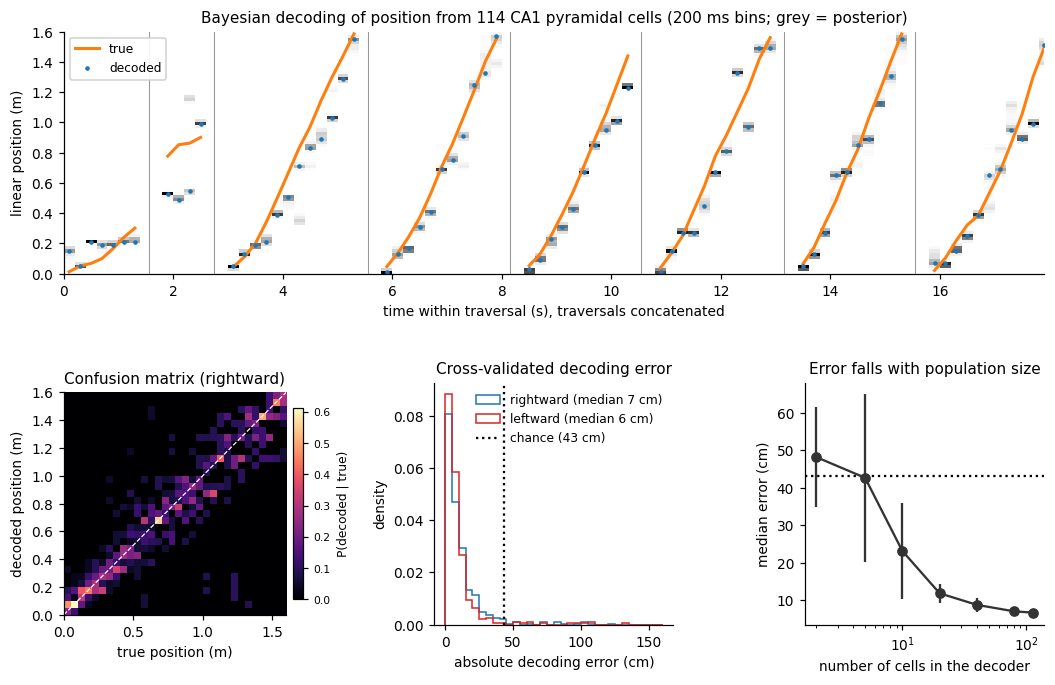

In [11]:
# a continuous stretch for illustration, decoded with a template from other laps
ill_ep = eps["right"]
train_ep = ill_ep[np.arange(len(ill_ep)) % 2 == 1]
_, cen_tr, _, tc_tr = L.rate_maps(pyr, lin, train_ep, minmax=minmax, return_xr=True)
show_i = np.arange(len(ill_ep))[np.arange(len(ill_ep)) % 2 == 0][:8]
show_ep = ill_ep[show_i]
dec_show, prob_show = nap.decode_bayes(tc_tr, pyr, show_ep, bin_size=0.2)
true_show = lin.interpolate(dec_show, ep=show_ep)

fig = plt.figure(figsize=(11.5, 7))
gs = GridSpec(2, 3, height_ratios=[1, 1], hspace=0.45, wspace=0.55)

ax = fig.add_subplot(gs[0, :])
# plot each traversal in its own horizontal slot so gaps do not stretch the axis
xcur = 0.0
for i in range(len(show_ep)):
    one = show_ep[i]
    m = (dec_show.t >= one.start[0]) & (dec_show.t <= one.end[0])
    if m.sum() < 2:
        continue
    tt = dec_show.t[m] - one.start[0] + xcur
    p = np.asarray(prob_show)[m]
    ax.pcolormesh(tt, cen_tr, p.T, cmap="Greys", shading="nearest")
    ax.plot(tt, true_show.values[m], color="#ff7f0e", lw=2,
            label="true" if i == show_i[0] else None)
    ax.plot(tt, dec_show.values[m], ".", color=RIGHT_C, ms=4,
            label="decoded" if i == show_i[0] else None)
    xcur = tt[-1] + 0.5
    ax.axvline(xcur - 0.25, color="0.6", lw=0.7)
ax.set_xlim(0, xcur - 0.5)
ax.set_xlabel("time within traversal (s), traversals concatenated")
ax.set_ylabel("linear position (m)")
ax.legend(loc="upper left", frameon=True, framealpha=0.9)
ax.set_title("Bayesian decoding of position from 114 CA1 pyramidal cells "
             "(200 ms bins; grey = posterior)")

ax = fig.add_subplot(gs[1, 0])
H, xe, ye = np.histogram2d(decode_out["right"]["true"], decode_out["right"]["decoded"],
                           bins=[np.linspace(*minmax, 33)] * 2)
H = H / np.maximum(H.sum(axis=1, keepdims=True), 1)
im = ax.imshow(H.T, origin="lower", extent=[*minmax, *minmax], aspect="equal",
               cmap="magma")
ax.plot(minmax, minmax, color="w", lw=0.8, ls="--")
cb = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, shrink=0.85)
cb.set_label("P(decoded | true)", fontsize=8)
cb.ax.tick_params(labelsize=7)
ax.set_xlabel("true position (m)")
ax.set_ylabel("decoded position (m)")
ax.set_title("Confusion matrix (rightward)")

ax = fig.add_subplot(gs[1, 1])
for d, c in (("right", RIGHT_C), ("left", LEFT_C)):
    e = 100 * decode_out[d]["err"]
    ax.hist(e, bins=np.arange(0, 165, 5), histtype="step", lw=1.7, color=c,
            density=True, label=f"{d}ward (median {np.median(e):.0f} cm)")
ax.axvline(100 * chance, color="k", ls=":", label=f"chance ({100 * chance:.0f} cm)")
ax.set_xlabel("absolute decoding error (cm)")
ax.set_ylabel("density")
ax.legend(frameon=False)
ax.set_title("Cross-validated decoding error")

ax = fig.add_subplot(gs[1, 2])
ncells = [2, 5, 10, 20, 40, 80, len(pyr)]
ncells = sorted(set([n for n in ncells if n <= len(pyr)]))
med_err = []
keys = np.array(list(pyr.keys()))
for n in tqdm(ncells, desc="decoding vs population size"):
    errs = []
    for rep in range(5):
        sub = nap.TsGroup({int(k): pyr[int(k)] for k in rng.choice(keys, n, replace=False)},
                          time_support=pyr.time_support)
        dec, true, _ = crossval_decode(sub, lin, eps["right"], minmax=minmax)
        errs.append(np.median(np.abs(dec - true)))
    med_err.append(errs)
med_err = 100 * np.array(med_err)
ax.errorbar(ncells, med_err.mean(1), yerr=med_err.std(1), marker="o", color="0.2")
ax.axhline(100 * chance, color="k", ls=":")
ax.set_xscale("log")
ax.set_xlabel("number of cells in the decoder")
ax.set_ylabel("median error (cm)")
ax.set_title("Error falls with population size")

fig.savefig(f"{FIGDIR}/fig06_decoding.png", bbox_inches="tight")
plt.show()

## 4. All five linear-track sessions

The pipeline is now re-run unchanged on the four remaining linear sessions
(four rats in total, one of them on a 2 m track), to check that the result is
not specific to one animal or one recording.

In [12]:
all_sessions = []
for spec in tqdm(L.SESSIONS, desc="sessions"):
    s = L.analyze_session(spec, n_shuffles=L.N_SHUFFLES, seed=7)
    dec, true, _ = crossval_decode(s["pyr"], s["lin"], s["eps"]["right"],
                                   minmax=s["minmax"])
    s["decode_err"] = np.abs(dec - true)
    s["chance_err"] = np.median(np.abs(rng.permutation(dec) - true))
    all_sessions.append(s)

sessions:   0%|          | 0/5 [00:00<?, ?it/s]

Achilles 10252013: maze 2068 s, 137 units, tracking valid on 13% of samples, dt=25.60 ms


shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

/Users/bdichter/dev/agent-foundational-studies/runs-2026-07-21-exploratory/opus-4-8/placefields-02/place_cells_lib.py:248: RuntimeWarning: invalid value encountered in divide
  return np.where(den > 0, num / den, np.nan)


...

  51 pyramidal units, 44 (86%) classified as place cells in at least one direction


Cicero 09172014: maze 3078 s, 72 units, tracking valid on 32% of samples, dt=25.60 ms


shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

shuffles:   0%|          | 0/500 [00:00<?, ?it/s]

  51 pyramidal units, 44 (86%) classified as place cells in at least one direction


In [13]:
summary = []
for s in all_sessions:
    r, spec = s["res"], s["session"]
    any_pc = r["right"]["is_place"] | r["left"]["is_place"]
    w = np.concatenate([r[d]["width"][r[d]["is_place"]] for d in ("right", "left")])
    si = np.concatenate([r[d]["si"][r[d]["is_place"]] for d in ("right", "left")])
    summary.append(dict(
        subject=spec["subject"], session=spec["session"], maze=spec["maze"],
        track_length_m=round(s["minmax"][1], 2),
        n_pyramidal=int(len(s["pyr"])),
        n_place_cells=int(any_pc.sum()),
        frac_place_cells=round(float(any_pc.mean()), 3),
        median_si=round(float(np.median(si)), 2),
        median_field_width_cm=round(float(100 * np.nanmedian(w)), 1),
        median_peak_rate_hz=round(float(np.median(np.concatenate(
            [r[d]["peak_rate"][r[d]["is_place"]] for d in ("right", "left")]))), 2),
        median_abs_DI=round(float(np.nanmedian(np.abs(L.directionality_index(r))[any_pc])), 2),
        decode_err_cm=round(float(100 * np.median(s["decode_err"])), 1),
        chance_err_cm=round(float(100 * s["chance_err"]), 1),
        run_time_s=round(float(s["eps"]["run"].tot_length()), 1),
        n_traversals=int(len(s["eps"]["run"])),
    ))

import pandas as pd
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))
summary_df.to_csv("session_summary.csv", index=False)

 subject  session           maze  track_length_m  n_pyramidal  n_place_cells  frac_place_cells  median_si  median_field_width_cm  median_peak_rate_hz  median_abs_DI  decode_err_cm  chance_err_cm  run_time_s  n_traversals
Achilles 10252013 1.6mLinearMaze             1.6          114             99             0.868       0.80                   23.0                 6.44           0.54            6.7           47.3       227.1           110
   Buddy 06272013 1.6mLinearMaze             1.6           36             29             0.806       0.84                   18.0                 3.86           0.50           12.5           46.5       148.9            78
  Cicero 09012014 1.6mLinearMaze             1.6           50             32             0.640       0.32                   29.0                 4.11           0.27           10.1           43.1       513.5           317
  Gatsby 08022013 1.6mLinearMaze             1.6           51             44             0.863       0.61           

### Figure 7: consistency across sessions and animals

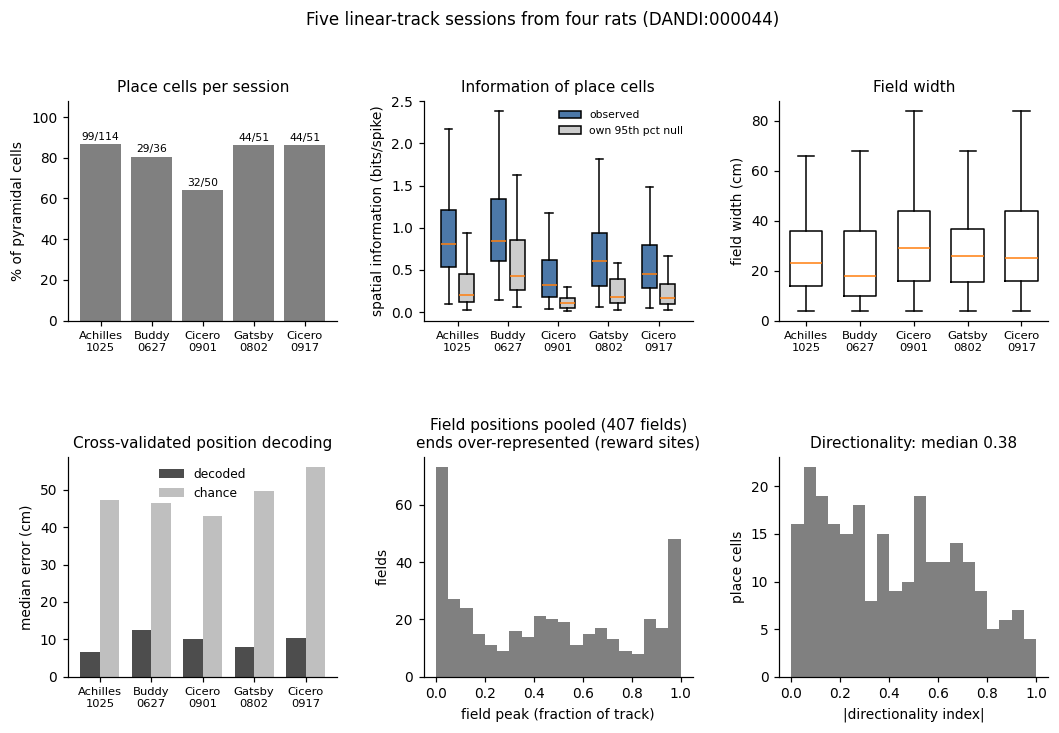

In [14]:
labels = [f"{r['subject']}\n{r['session'][:4]}" for r in summary]  # MMDD of the session date
x = np.arange(len(summary))

fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.8))
fig.subplots_adjust(hspace=0.62, wspace=0.32)

ax = axes[0, 0]
ax.bar(x, [r["frac_place_cells"] * 100 for r in summary], color="0.5")
for i, r in enumerate(summary):
    ax.text(i, r["frac_place_cells"] * 100 + 2, f"{r['n_place_cells']}/{r['n_pyramidal']}",
            ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("% of pyramidal cells")
ax.set_ylim(0, 108)
ax.set_title("Place cells per session")

ax = axes[0, 1]
obs = [np.concatenate([s["res"][d]["si"][s["res"][d]["is_place"]]
                       for d in ("right", "left")]) for s in all_sessions]
# each unit's own 95th-percentile null threshold, for the same units
thr = [np.concatenate([np.percentile(s["res"][d]["null"], 95, axis=0)[s["res"][d]["is_place"]]
                       for d in ("right", "left")]) for s in all_sessions]
b1 = ax.boxplot(obs, positions=x - 0.18, widths=0.3, showfliers=False,
                patch_artist=True)
b2 = ax.boxplot(thr, positions=x + 0.18, widths=0.3, showfliers=False,
                patch_artist=True)
for box in b1["boxes"]:
    box.set_facecolor("#4c78a8")
for box in b2["boxes"]:
    box.set_facecolor("0.8")
ax.legend([b1["boxes"][0], b2["boxes"][0]],
          ["observed", "own 95th pct null"], frameon=False, fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("spatial information (bits/spike)")
ax.set_title("Information of place cells")

ax = axes[0, 2]
data = [100 * np.concatenate([s["res"][d]["width"][s["res"][d]["is_place"]]
                              for d in ("right", "left")]) for s in all_sessions]
data = [d[np.isfinite(d)] for d in data]
ax.boxplot(data, positions=x, widths=0.6, showfliers=False)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("field width (cm)")
ax.set_title("Field width")

ax = axes[1, 0]
ax.bar(x - 0.19, [r["decode_err_cm"] for r in summary], width=0.38, color="0.3",
       label="decoded")
ax.bar(x + 0.19, [r["chance_err_cm"] for r in summary], width=0.38, color="0.75",
       label="chance")
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylabel("median error (cm)")
ax.legend(frameon=False)
ax.set_title("Cross-validated position decoding")

ax = axes[1, 1]
allpk = np.concatenate([s["res"][d]["peak_pos"][s["res"][d]["is_place"]] / s["minmax"][1]
                        for s in all_sessions for d in ("right", "left")])
ax.hist(allpk, bins=np.linspace(0, 1, 21), color="0.5")
ax.set_xlabel("field peak (fraction of track)")
ax.set_ylabel("fields")
ax.set_title(f"Field positions pooled ({allpk.size} fields)\n"
             "ends over-represented (reward sites)")

ax = axes[1, 2]
alldi = np.concatenate([np.abs(L.directionality_index(s["res"]))[
    s["res"]["right"]["is_place"] | s["res"]["left"]["is_place"]] for s in all_sessions])
ax.hist(alldi[np.isfinite(alldi)], bins=np.linspace(0, 1, 21), color="0.5")
ax.set_xlabel("|directionality index|")
ax.set_ylabel("place cells")
ax.set_title(f"Directionality: median {np.nanmedian(alldi):.2f}")

fig.suptitle("Five linear-track sessions from four rats (DANDI:000044)", y=1.0,
             fontsize=11)
fig.savefig(f"{FIGDIR}/fig07_multisession.png", bbox_inches="tight")
plt.show()

## Results

In [15]:
pooled_pc = sum(r["n_place_cells"] for r in summary)
pooled_pyr = sum(r["n_pyramidal"] for r in summary)
stats = dict(
    dandiset="DANDI:000044",
    n_sessions=len(summary),
    n_subjects=len(set(r["subject"] for r in summary)),
    n_pyramidal_total=pooled_pyr,
    n_place_cells_total=pooled_pc,
    frac_place_cells=round(pooled_pc / pooled_pyr, 3),
    median_si_bits_per_spike=round(float(np.median(np.concatenate(
        [np.concatenate([s["res"][d]["si"][s["res"][d]["is_place"]]
                         for d in ("right", "left")]) for s in all_sessions]))), 2),
    median_field_width_cm=round(float(np.nanmedian(np.concatenate(
        [np.concatenate([s["res"][d]["width"][s["res"][d]["is_place"]]
                         for d in ("right", "left")]) for s in all_sessions]))) * 100, 1),
    median_abs_directionality=round(float(np.nanmedian(alldi[np.isfinite(alldi)])), 2),
    median_decode_error_cm=round(float(np.median([r["decode_err_cm"] for r in summary])), 1),
    median_chance_error_cm=round(float(np.median([r["chance_err_cm"] for r in summary])), 1),
)
with open("results_summary.json", "w") as fh:
    json.dump(dict(summary=stats, per_session=summary), fh, indent=2)
for k, v in stats.items():
    print(f"{k:32s} {v}")

dandiset                         DANDI:000044
n_sessions                       5
n_subjects                       4
n_pyramidal_total                302
n_place_cells_total              248
frac_place_cells                 0.821
median_si_bits_per_spike         0.65
median_field_width_cm            24.0
median_abs_directionality        0.38
median_decode_error_cm           10.1
median_chance_error_cm           47.3


**What the data show.**  Across five linear-track sessions from four rats, 248
of the 302 dorsal-CA1 pyramidal cells that were active on the track (82%) had a
statistically reliable place field in at least one travel direction: their
Skaggs spatial information exceeded the 95th percentile of a circular-shift
null built from their own spike trains, and their peak in-field rate was
several times their mean rate over the track.  Fields were compact (median
width at half maximum 24 cm on tracks of 1.6 to 2 m), they covered the whole
track with no large gaps, and they were strongly direction selective: sorting
the population by rightward field location produces a clean diagonal for
rightward runs and an unstructured map for leftward runs over the same cells.

The population code is accurate enough to invert.  A Bayesian decoder trained
on half the traversals and tested on the other half recovered the animal's
position on the held-out laps to a median absolute error of 10 cm in 200-250 ms
bins, against a chance level of 47 cm, and the error fell monotonically as more
cells were added to the decoder.  Together these are the textbook signatures of
the hippocampal place code, reproduced here directly from archived data with a
pipeline that streams the recordings rather than downloading them.